# Results Analysis — CNN vs Vision Transformer

Aggregates the five trained variants: metrics table, accuracy/cost trade-off,
per-variant confusion matrices and training curves, and the saliency comparison.

In [1]:
import csv, json, shutil
from pathlib import Path
import matplotlib.pyplot as plt

VARIANTS = ["resnet50", "vit_b16_ft", "vit_s16_scratch", "deit_s16_ft", "vit_b16_linprobe"]
EXP = Path("../experiments")
FIG = Path("../report/figures")
FIG.mkdir(parents=True, exist_ok=True)

rows = []
for v in VARIANTS:
    meta = json.loads((EXP / v / "metadata.json").read_text())
    test = json.loads((EXP / v / "test_metrics.json").read_text())
    rows.append({
        "variant": v,
        "total_params_M": round(meta["total_params"] / 1e6, 2),
        "trainable_params_M": round(meta["trainable_params"] / 1e6, 4),
        "train_time_min": round(meta["train_time_sec"] / 60, 1),
        "epochs_run": meta["epochs_run"],
        "best_val_acc": round(meta["best_val_acc"], 4),
        "test_acc": round(test["accuracy"], 4),
        "macro_precision": round(test["macro_precision"], 4),
        "macro_recall": round(test["macro_recall"], 4),
        "macro_f1": round(test["macro_f1"], 4),
    })
for r in rows:
    print(r)


{'variant': 'resnet50', 'total_params_M': 23.58, 'trainable_params_M': 23.5838, 'train_time_min': 6.3, 'epochs_run': 20, 'best_val_acc': 0.9497, 'test_acc': 0.925, 'macro_precision': 0.9267, 'macro_recall': 0.9245, 'macro_f1': 0.9242}
{'variant': 'vit_b16_ft', 'total_params_M': 85.83, 'trainable_params_M': 85.8271, 'train_time_min': 21.4, 'epochs_run': 20, 'best_val_acc': 0.9524, 'test_acc': 0.9368, 'macro_precision': 0.9382, 'macro_recall': 0.9364, 'macro_f1': 0.9358}
{'variant': 'vit_s16_scratch', 'total_params_M': 21.68, 'trainable_params_M': 21.6799, 'train_time_min': 19.5, 'epochs_run': 60, 'best_val_acc': 0.2826, 'test_acc': 0.227, 'macro_precision': 0.2257, 'macro_recall': 0.2272, 'macro_f1': 0.221}
{'variant': 'deit_s16_ft', 'total_params_M': 21.68, 'trainable_params_M': 21.6799, 'train_time_min': 5.8, 'epochs_run': 20, 'best_val_acc': 0.947, 'test_acc': 0.9272, 'macro_precision': 0.9285, 'macro_recall': 0.9268, 'macro_f1': 0.9262}
{'variant': 'vit_b16_linprobe', 'total_params_

In [2]:
fields = ["variant", "total_params_M", "trainable_params_M", "train_time_min",
          "epochs_run", "best_val_acc", "test_acc", "macro_precision",
          "macro_recall", "macro_f1"]
with open(FIG / "results_table.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(rows)
print("wrote", FIG / "results_table.csv")


wrote ../report/figures/results_table.csv


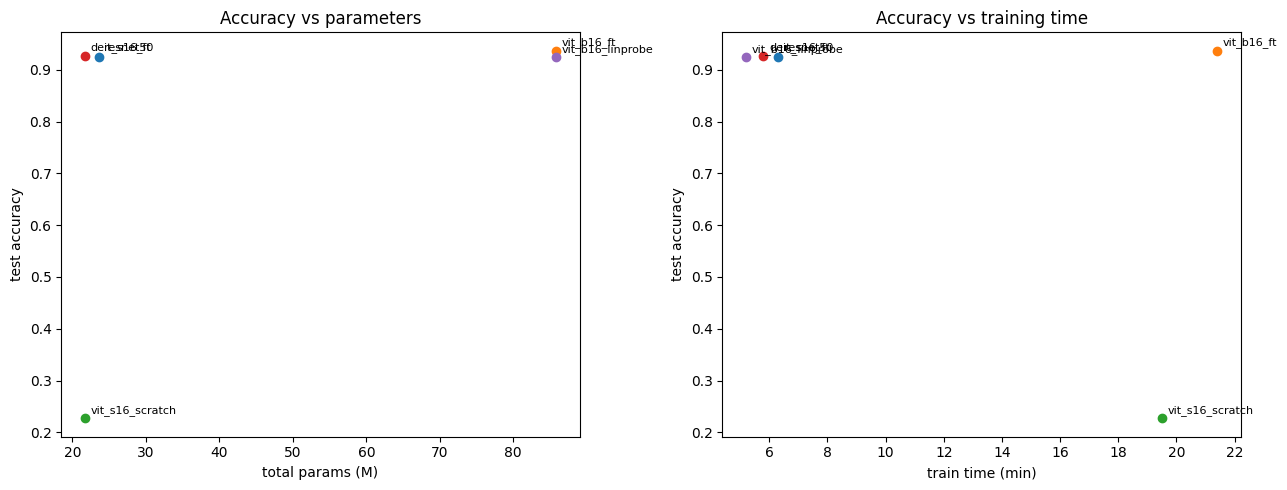

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for r in rows:
    ax1.scatter(r["total_params_M"], r["test_acc"])
    ax1.annotate(r["variant"], (r["total_params_M"], r["test_acc"]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")
ax1.set_xlabel("total params (M)")
ax1.set_ylabel("test accuracy")
ax1.set_title("Accuracy vs parameters")
for r in rows:
    ax2.scatter(r["train_time_min"], r["test_acc"])
    ax2.annotate(r["variant"], (r["train_time_min"], r["test_acc"]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")
ax2.set_xlabel("train time (min)")
ax2.set_ylabel("test accuracy")
ax2.set_title("Accuracy vs training time")
fig.tight_layout()
fig.savefig(FIG / "accuracy_vs_params.png", dpi=150)
plt.show()


In [4]:
for v in VARIANTS:
    shutil.copy(EXP / v / "confusion_matrix.png", FIG / f"{v}_confusion_matrix.png")
    shutil.copy(EXP / v / "curves.png", FIG / f"{v}_curves.png")
print("copied per-variant confusion matrices and curves")


copied per-variant confusion matrices and curves


## Saliency comparison — original | CNN Grad-CAM | ViT attention

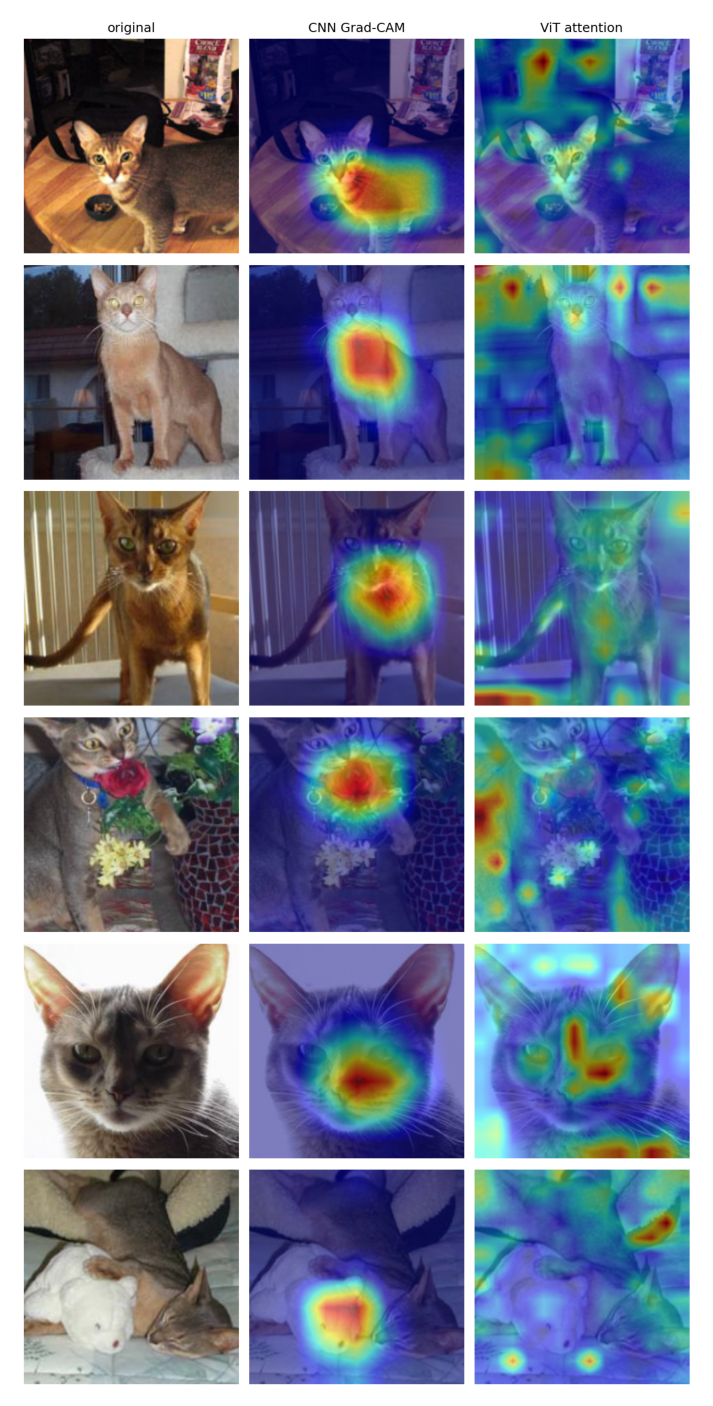

In [5]:
from matplotlib.image import imread
img = imread(FIG / "comparison.png")
fig, ax = plt.subplots(figsize=(9, 18))
ax.imshow(img)
ax.axis("off")
plt.show()
